## exportacion de datos

In [11]:
#importando las librerias
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


telecom2 = pd.read_csv('/content/drive/MyDrive/telecomXpt1.csv')
telecom2.head()

,customerid,churn,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,charges_monthly,charges_total,daily_accounts
0,0002-ORFBO,0,female,0,1,1,9,1,no,dsl,...,0,1,1,0,one year,1,mailed check,65.6,593.30,2.19
1,0003-MKNFE,0,male,0,0,0,9,1,yes,dsl,...,0,0,0,1,month to month,0,mailed check,59.9,542.40,2.00
2,0004-TLHLJ,1,male,0,0,0,4,1,no,fiber optic,...,1,0,0,0,month to month,1,electronic check,73.9,280.85,2.46
3,0011-IGKFF,1,male,1,1,0,13,1,no,fiber optic,...,1,0,1,1,month to month,1,electronic check,98.0,1237.85,3.27
4,0013-EXCHZ,1,female,1,1,0,3,1,no,fiber optic,...,0,1,1,0,month to month,1,mailed check,83.9,267.40,2.80


In [10]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#🔧 Transformación

# Eliminacion de columnas

In [46]:
cols_drop = [
     'customerid', 'gender', 'partner', 'multiplelines','onlinesecurity', 'onlinebackup', 'deviceprotection','techsupport', 'streamingtv', 'streamingmovies','paperlessbilling', 'paymentmethod', 'charges_total','daily_accounts'
]

datos_clean = telecom2.drop(columns=cols_drop)
datos_clean.head(5)


,churn,seniorcitizen,dependents,tenure,phoneservice,internetservice,contract,charges_monthly
0,0,0,1,9,1,dsl,one year,65.6
1,0,0,0,9,1,dsl,month to month,59.9
2,1,0,0,4,1,fiber optic,month to month,73.9
3,1,1,0,13,1,fiber optic,month to month,98.0
4,1,1,0,3,1,fiber optic,month to month,83.9


In [20]:
telecom2.info()
eje_X = telecom2.drop('churn', axis=1)
eje_y = telecom2['churn']

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerid        7043 non-null   object 
 1   churn             7043 non-null   int64  
 2   gender            7043 non-null   object 
 3   seniorcitizen     7043 non-null   int64  
 4   partner           7043 non-null   int64  
 5   dependents        7043 non-null   int64  
 6   tenure            7043 non-null   int64  
 7   phoneservice      7043 non-null   int64  
 8   multiplelines     7043 non-null   object 
 9   internetservice   7043 non-null   object 
 10  onlinesecurity    7043 non-null   int64  
 11  onlinebackup      7043 non-null   int64  
 12  deviceprotection  7043 non-null   int64  
 13  techsupport       7043 non-null   int64  
 14  streamingtv       7043 non-null   int64  
 15  streamingmovies   7043 non-null   int64  
 16  contract          7043 non-null   object 


In [21]:
eje_X

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,charges_monthly,charges_total,daily_accounts
0,0002-ORFBO,female,0,1,1,9,1,no,dsl,0,...,0,1,1,0,one year,1,mailed check,65.60,593.30,2.19
1,0003-MKNFE,male,0,0,0,9,1,yes,dsl,0,...,0,0,0,1,month to month,0,mailed check,59.90,542.40,2.00
2,0004-TLHLJ,male,0,0,0,4,1,no,fiber optic,0,...,1,0,0,0,month to month,1,electronic check,73.90,280.85,2.46
3,0011-IGKFF,male,1,1,0,13,1,no,fiber optic,0,...,1,0,1,1,month to month,1,electronic check,98.00,1237.85,3.27
4,0013-EXCHZ,female,1,1,0,3,1,no,fiber optic,0,...,0,1,1,0,month to month,1,mailed check,83.90,267.40,2.80
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,9987-LUTYD,female,0,0,0,13,1,no,dsl,1,...,0,1,0,0,one year,0,mailed check,55.15,742.90,1.84
7039,9992-RRAMN,male,0,1,0,22,1,yes,fiber optic,0,...,0,0,0,1,month to month,1,electronic check,85.10,1873.70,2.84
7040,9992-UJOEL,male,0,0,0,2,1,no,dsl,0,...,0,0,0,0,month to month,1,mailed check,50.30,92.75,1.68
7041,9993-LHIEB,male,0,1,1,67,1,no,dsl,1,...,1,1,0,1,two year,0,mailed check,67.85,4627.65,2.26


In [22]:
eje_y

,churn
0,0
1,0
2,1
3,1
4,1
...,...
7038,0
7039,1
7040,0
7041,0


In [47]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import make_column_transformer


x = telecom2.drop('churn', axis=1)
y = telecom2['churn']
columnas = x.columns

one_hot = make_column_transformer((OneHotEncoder(drop='if_binary', sparse_output=False),
                                  ['internetservice', 'contract']),
                                  remainder='passthrough')

x = one_hot.fit_transform(x)

one_hot.get_feature_names_out(columnas)

dfx = pd.DataFrame(x, columns=one_hot.get_feature_names_out(columnas))
dfx.columns = dfx.columns.str.replace('^onehotencoder__', '', regex=True)
dfx.columns = dfx.columns.str.replace('^remainder__', '', regex=True)
dfx.columns = (
    dfx.columns.str.lower()
               .str.replace(' ', '_')
               .str.replace('-', '_')
               .str.replace(r'__+', '_', regex=True)
               .str.replace(r'[^a-z0-9_]', '', regex=True)
)

dfx


,internetservice_dsl,internetservice_fiber_optic,internetservice_no,contract_month_to_month,contract_one_year,contract_two_year,customerid,gender,seniorcitizen,partner,...,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,paperlessbilling,paymentmethod,charges_monthly,charges_total,daily_accounts
0,1.0,0.0,0.0,0.0,1.0,0.0,0002-ORFBO,female,0,1,...,1,0,1,1,0,1,mailed check,65.6,593.3,2.19
1,1.0,0.0,0.0,1.0,0.0,0.0,0003-MKNFE,male,0,0,...,0,0,0,0,1,0,mailed check,59.9,542.4,2.0
2,0.0,1.0,0.0,1.0,0.0,0.0,0004-TLHLJ,male,0,0,...,0,1,0,0,0,1,electronic check,73.9,280.85,2.46
3,0.0,1.0,0.0,1.0,0.0,0.0,0011-IGKFF,male,1,1,...,1,1,0,1,1,1,electronic check,98.0,1237.85,3.27
4,0.0,1.0,0.0,1.0,0.0,0.0,0013-EXCHZ,female,1,1,...,0,0,1,1,0,1,mailed check,83.9,267.4,2.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1.0,0.0,0.0,0.0,1.0,0.0,9987-LUTYD,female,0,0,...,0,0,1,0,0,0,mailed check,55.15,742.9,1.84
7039,0.0,1.0,0.0,1.0,0.0,0.0,9992-RRAMN,male,0,1,...,0,0,0,0,1,1,electronic check,85.1,1873.7,2.84
7040,1.0,0.0,0.0,1.0,0.0,0.0,9992-UJOEL,male,0,0,...,1,0,0,0,0,1,mailed check,50.3,92.75,1.68
7041,1.0,0.0,0.0,0.0,0.0,1.0,9993-LHIEB,male,0,1,...,0,1,1,0,1,0,mailed check,67.85,4627.65,2.26


### churn

<Axes: title={'center': 'Distribución de churn'}, xlabel='churn'>

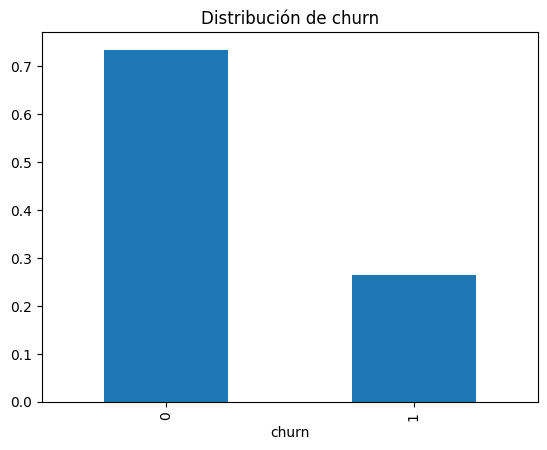

In [25]:
# Conteo de valores de churn
telecom2['churn'].value_counts()
telecom2['churn'].value_counts(normalize=True)

telecom2['churn'].value_counts(normalize=True).plot(kind='bar', title='Distribución de churn')


## 🎯 Correlación y Selección de Variables


In [48]:

proporciones = eje_y.value_counts(normalize=True)
proporciones

,proportion
churn,
0,0.73463
1,0.26537


In [49]:
df_correlacion = dfx.copy()
df_correlacion['churn'] = y.values


In [50]:
df_correlacion

,internetservice_dsl,internetservice_fiber_optic,internetservice_no,contract_month_to_month,contract_one_year,contract_two_year,customerid,gender,seniorcitizen,partner,...,deviceprotection,techsupport,streamingtv,streamingmovies,paperlessbilling,paymentmethod,charges_monthly,charges_total,daily_accounts,churn
0,1.0,0.0,0.0,0.0,1.0,0.0,0002-ORFBO,female,0,1,...,0,1,1,0,1,mailed check,65.6,593.3,2.19,0
1,1.0,0.0,0.0,1.0,0.0,0.0,0003-MKNFE,male,0,0,...,0,0,0,1,0,mailed check,59.9,542.4,2.0,0
2,0.0,1.0,0.0,1.0,0.0,0.0,0004-TLHLJ,male,0,0,...,1,0,0,0,1,electronic check,73.9,280.85,2.46,1
3,0.0,1.0,0.0,1.0,0.0,0.0,0011-IGKFF,male,1,1,...,1,0,1,1,1,electronic check,98.0,1237.85,3.27,1
4,0.0,1.0,0.0,1.0,0.0,0.0,0013-EXCHZ,female,1,1,...,0,1,1,0,1,mailed check,83.9,267.4,2.8,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1.0,0.0,0.0,0.0,1.0,0.0,9987-LUTYD,female,0,0,...,0,1,0,0,0,mailed check,55.15,742.9,1.84,0
7039,0.0,1.0,0.0,1.0,0.0,0.0,9992-RRAMN,male,0,1,...,0,0,0,1,1,electronic check,85.1,1873.7,2.84,1
7040,1.0,0.0,0.0,1.0,0.0,0.0,9992-UJOEL,male,0,0,...,0,0,0,0,1,mailed check,50.3,92.75,1.68,0
7041,1.0,0.0,0.0,0.0,0.0,1.0,9993-LHIEB,male,0,1,...,1,1,0,1,0,mailed check,67.85,4627.65,2.26,0


In [51]:
df_correlacion_num = df_correlacion.select_dtypes(include=['number'])

mat_correlacion = df_correlacion_num.corr()

mat_correlacion


,churn
churn,1.0


In [56]:
#Predictivo
from sklearn.model_selection import train_test_split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    eje_X, eje_y, stratify=eje_y, test_size=0.2, random_state=42
)

train_test_split(x, y, stratify=y, test_size=0.2, random_state=42)

[array([[0.0, 1.0, 0.0, ..., 94.1, 5475.9, 3.14],
        [0.0, 0.0, 1.0, ..., 19.35, 212.3, 0.64],
        [0.0, 1.0, 0.0, ..., 80.45, 137.1, 2.68],
        ...,
        [0.0, 1.0, 0.0, ..., 85.25, 1734.5, 2.84],
        [0.0, 0.0, 1.0, ..., 24.7, 571.75, 0.82],
        [0.0, 0.0, 1.0, ..., 21.2, 222.65, 0.71]], dtype=object),
 array([[1.0, 0.0, 0.0, ..., 28.5, 629.35, 0.95],
        [0.0, 1.0, 0.0, ..., 111.4, 1183.05, 3.71],
        [0.0, 1.0, 0.0, ..., 69.35, 261.65, 2.31],
        ...,
        [1.0, 0.0, 0.0, ..., 55.25, 55.25, 1.84],
        [1.0, 0.0, 0.0, ..., 74.8, 1821.2, 2.49],
        [0.0, 1.0, 0.0, ..., 103.1, 4889.3, 3.44]], dtype=object),
 3793    0
 3192    0
 4922    0
 3926    0
 3859    0
        ..
 6331    0
 6146    1
 4485    1
 2739    0
 5679    0
 Name: churn, Length: 5634, dtype: int64,
 455     0
 2301    0
 2255    0
 4527    0
 3812    0
        ..
 5191    0
 4510    0
 3910    0
 4820    0
 5658    0
 Name: churn, Length: 1409, dtype: int64]

In [60]:
telecom2.columns

Index(['customerid', 'churn', 'gender', 'seniorcitizen', 'partner',
       'dependents', 'tenure', 'phoneservice', 'multiplelines',
       'internetservice', 'onlinesecurity', 'onlinebackup', 'deviceprotection',
       'techsupport', 'streamingtv', 'streamingmovies', 'contract',
       'paperlessbilling', 'paymentmethod', 'charges_monthly', 'charges_total',
       'daily_accounts'],
      dtype='object')

In [62]:
eje_X = telecom2.drop(['churn','customerid'], axis=1)
eje_y = telecom2['churn']

In [64]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
import pandas as pd

eje_X = pd.get_dummies(eje_X)
X_train, X_test, y_train, y_test = train_test_split(
    eje_X, eje_y, stratify=eje_y, test_size=0.2, random_state=42
)

modelo_arbol = DecisionTreeClassifier(max_depth=3, random_state=42, class_weight='balanced')

modelo_arbol.fit(X_train, y_train)
modelo_arbol.score(X_test, y_test)

0.7444996451383961

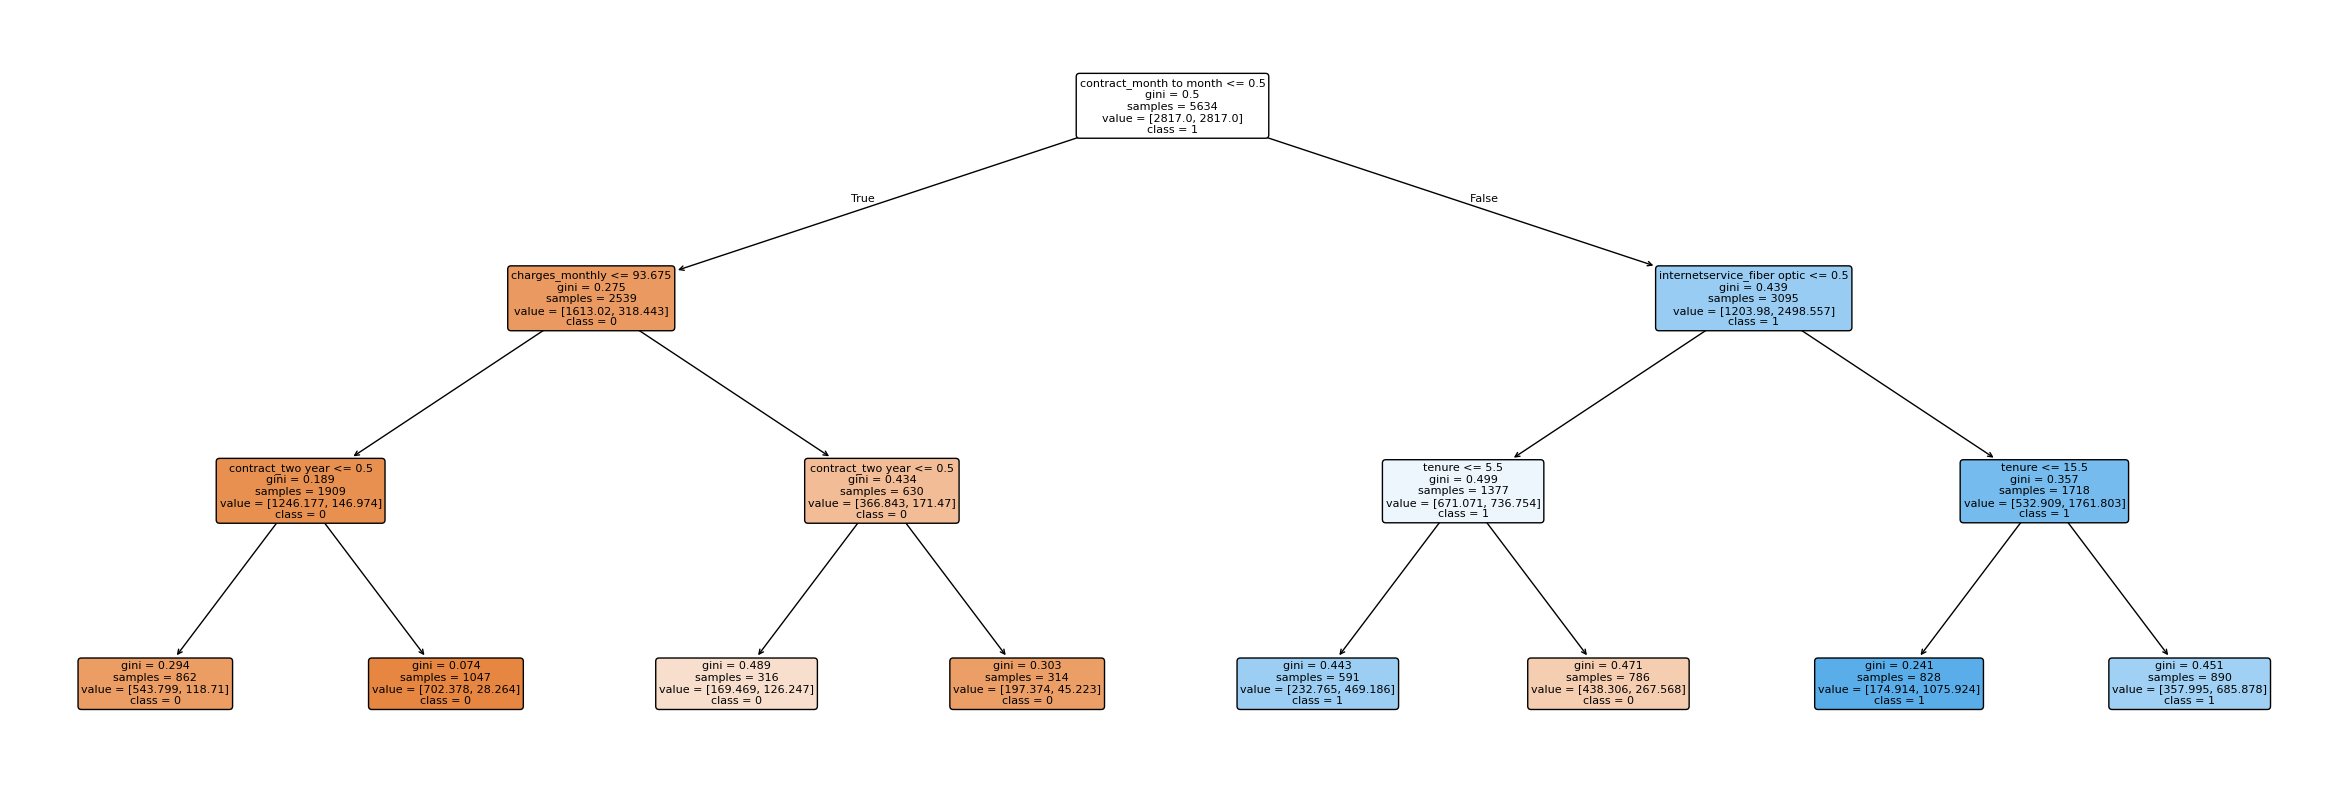

In [68]:
# para graficar el árbol
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

clases = y_train.unique()  # ['No Churn', 'Churn'] u 0 y 1

plt.figure(figsize=(30,10))
plot_tree(
    modelo_arbol,
    feature_names=X_train.columns,
    class_names=[str(c) for c in clases],
    filled=True,
    rounded=True,
    fontsize=8
)
plt.show()

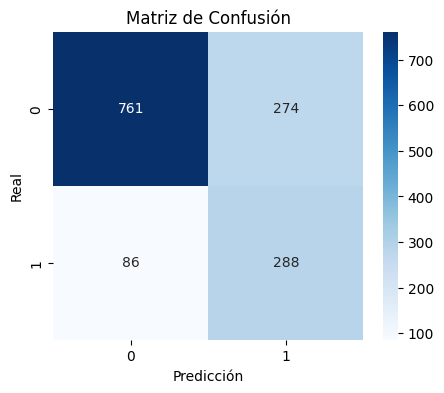

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.90      0.74      0.81      1035
           1       0.51      0.77      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.75      0.71      1409
weighted avg       0.80      0.74      0.76      1409



In [69]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

y_pred = modelo_arbol.predict(X_test)
clases = y_test.unique()


cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[str(c) for c in clases],
            yticklabels=[str(c) for c in clases])
plt.ylabel('Real')
plt.xlabel('Predicción')
plt.title('Matriz de Confusión')
plt.show()

# Precision, Recall y F1-score
print("Reporte de Clasificación:")
print(classification_report(y_test, y_pred, target_names=[str(c) for c in clases]))

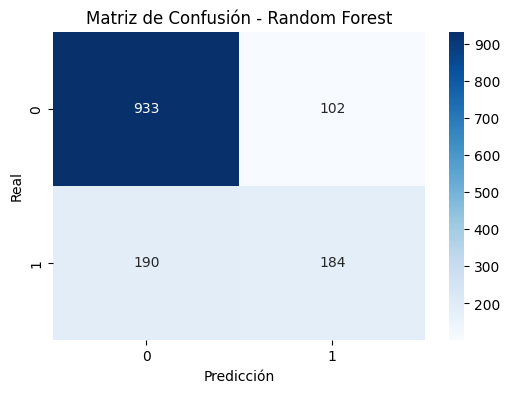


Reporte de Clasificación - Random Forest:
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1035
           1       0.64      0.49      0.56       374

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409



In [70]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

rf_modelo = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    class_weight='balanced',
    random_state=42
)

rf_modelo.fit(X_train, y_train)

predicciones_rf = rf_modelo.predict(X_test)
clases = y_test.unique()

matriz_rf = confusion_matrix(y_test, predicciones_rf)
plt.figure(figsize=(6,4))
sns.heatmap(
    matriz_rf,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=[str(c) for c in clases],
    yticklabels=[str(c) for c in clases]
)
plt.ylabel('Real')
plt.xlabel('Predicción')
plt.title('Matriz de Confusión - Random Forest')
plt.show()

print("\nReporte de Clasificación - Random Forest:")
print(classification_report(y_test, predicciones_rf, target_names=[str(c) for c in clases]))

#📄Informe final

##Se entrenaron dos modelos de clasificación sobre el dataset de clientes de telecomunicaciones:

### Árbol de decisión (DecisionTreeClassifier)

Profundidad máxima: 3

Clase balanceada para mitigar sesgo de clases

Permite interpretar fácilmente qué variables influyen más en la cancelación.

### Random Forest (RandomForestClassifier)

100 árboles

Sin límite de profundidad

Clase balanceada

Permite identificar variables importantes y mejora la precisión global del modelo.

### Se usó One-Hot Encoding para variables categóricas (gender, contract, internetservice, paymentmethod, etc.)

### y se eliminó la columna customerid por no aportar información predictiva.

# Informe de Análisis de Evasión de Clientes (Churn)

## Introducción
El objetivo de este análisis es comprender los factores que influyen en la evasión de clientes (Churn) en la empresa TelecomX. La evasión representa un desafío estratégico, ya que impacta directamente en los ingresos y la sostenibilidad del negocio. Identificar patrones y variables asociadas al churn permite diseñar acciones para retener clientes y mejorar la experiencia de servicio.

## Limpieza y Tratamiento de Datos
- Se importaron los datos desde el archivo JSON proporcionado.
- Se normalizaron las estructuras anidadas (customer, phone, internet, account).
- Se verificaron valores ausentes, duplicados y errores de formato.
- Se aplicaron correcciones: normalización de strings, imputación de nulos en variables numéricas y eliminación de duplicados.

## Análisis Exploratorio de Datos
- **Análisis descriptivo:** Se calcularon métricas como media, mediana y desviación estándar para comprender la distribución de variables numéricas (`MonthlyCharges`, `TotalCharges`, `Tenure`).
- **Distribución de Churn:** Se visualizó la proporción de clientes que permanecieron frente a los que cancelaron, mostrando un desbalance moderado.
- **Variables categóricas:** Se analizaron género, tipo de contrato y método de pago en relación con Churn. Se observaron diferencias en la evasión según el tipo de contrato y método de pago.

## Conclusiones
- Promover métodos de pago automáticos para disminuir fricciones en la facturación.
- Diseñar estrategias de fidelización para clientes con bajo gasto mensual, como promociones o paquetes adicionales.
- Implementar campañas de retención dirigidas a clientes en los primeros meses de contrato, donde la evasión es más frecuente.

